    rel       ret     abret       car       date       vol
0   -20 -0.002613 -0.009413 -0.009413 2025-10-23  11408241
1   -19 -0.006457 -0.014557 -0.023970 2025-10-24  10317959
2   -18 -0.016012 -0.028012 -0.051983 2025-10-27  16375860
3   -17 -0.012444 -0.014444 -0.066426 2025-10-28  13322994
4   -16 -0.006882 -0.006182 -0.072608 2025-10-29  11986407
5   -15 -0.002245  0.008555 -0.064053 2025-10-30  14065077
6   -14 -0.010271 -0.014471 -0.078524 2025-10-31  20237018
7   -13  0.004052  0.002652 -0.075872 2025-11-03  14811687
8   -12  0.006694  0.019094 -0.056778 2025-11-04  12636350
9   -11 -0.007822 -0.012222 -0.069001 2025-11-05  13356821
10  -10  0.002070  0.013970 -0.055031 2025-11-06  14866025
11   -9  0.008950  0.007450 -0.047581 2025-11-07  17248716
12   -8 -0.001657 -0.016957 -0.064538 2025-11-10  14507603
13   -7  0.009959  0.007959 -0.056579 2025-11-11  13182144
14   -6  0.000000 -0.000500 -0.057079 2025-11-12  12084407
15   -5 -0.008701  0.008999 -0.048080 2025-11-13  180885

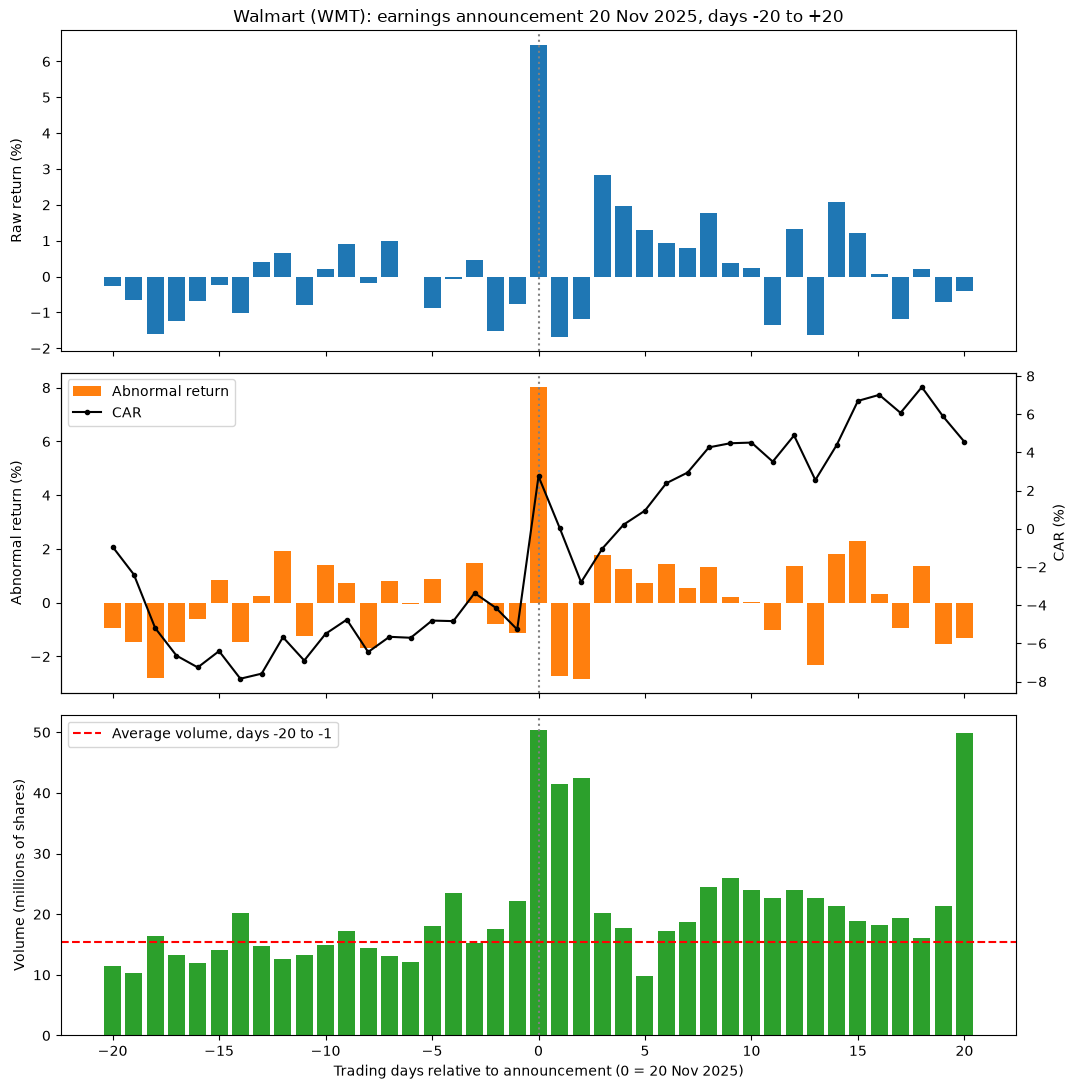

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

EVENT_DATE  = pd.Timestamp("2025-11-20")
EVENT_FILE  = "wmt_event.csv"
VOLUME_FILE = "wmt_volume.csv"



# WRDS Event Study Data
ev = pd.read_csv(EVENT_FILE) # reads the file
ev = ev[["evttime", "ret_m", "abret_m", "car_m"]] #keeps only these columns
ev = ev.rename(columns={"evttime": "rel", "ret_m": "ret", "abret_m": "abret", "car_m": "car"}) #rename columns

# WRDS Compustat Data
px = pd.read_csv(VOLUME_FILE) #read the volume file
px.columns = [c.lower() for c in px.columns] #lowers the column names

#Alternatively
#(new_names = []
#for c in px.columns:
#   new_names.append(c.lower())

px = px.rename(columns={"dlycaldt": "date", "dlyvol": "vol"}) #rename colums

px["date"] = pd.to_datetime(px["date"]) #turns text into date format
px = px.sort_values("date").reset_index(drop=True) #puts the rows in date order, oldest first. (might not be in order, renumbers the rows 0, 1, 2, 3 and so on. Sorting shuffles the row numbers along with the rows, so you’d see something like 5, 2, 9. To make this clean, reset the index to 0, 1, 2.), drop duplicates

#We do this to match volume data with the event study data. The event study data is in relative days, so we need to create a relative day column in the volume data as well.
pos0 = px.index[px["date"] == EVENT_DATE][0] #find the position of the event date in the index. This is a list, so we take the first element with [0], this a boolean True or False so only one date should remain which is our event date.

#print(px.head()) to verify postion vs relative position
px["rel"] = px.index - pos0 #creates a new column called rel, which is the index minus the position of the event date. This gives us a relative day count, with 0 being the event date, negative numbers before, and positive numbers after.

base = px[(px["rel"] >= -20) & (px["rel"] <= -1)]["vol"].mean()  #calculates the average volume for the 20 days before the event date, which we will use as a baseline for comparison in the volume chart.

df = ev.merge(px[["rel", "date", "vol"]], on="rel", how="left") #matches the two dataframes on the relative day column, keeping all rows from the event study data and adding the volume data where available.
print(df) #check if worked

#Creates the graphs and charts
fig, ax = plt.subplots(3, 1, figsize=(11, 11), sharex=True)

ax[0].bar(df["rel"], df["ret"] * 100, color="tab:blue")
ax[0].set_ylabel("Raw return (%)")
ax[0].set_title("Walmart (WMT): earnings announcement 20 Nov 2025, days -20 to +20")

ax[1].bar(df["rel"], df["abret"] * 100, color="tab:orange", label="Abnormal return")
ax[1].set_ylabel("Abnormal return (%)")
ax2 = ax[1].twinx()
ax2.plot(df["rel"], df["car"] * 100, color="black", marker="o", ms=3, label="CAR")
ax2.set_ylabel("CAR (%)")
h1, l1 = ax[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax[1].legend(h1 + h2, l1 + l2, loc="upper left")

ax[2].bar(df["rel"], df["vol"] / 1e6, color="tab:green")
ax[2].axhline(base / 1e6, color="red", ls="--", label="Average volume, days -20 to -1")
ax[2].set_ylabel("Volume (millions of shares)")
ax[2].set_xlabel("Trading days relative to announcement (0 = 20 Nov 2025)")
ax[2].legend()

for a in ax:
    a.axvline(0, color="grey", ls=":")

plt.tight_layout()
plt.savefig("walmart_event_study.png", dpi=150)
plt.show()

